# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc  # Garbage Collector for memory management

# The New Stack: PyTorch, NCA, Isolation Forests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Processing Unit: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Config
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

Processing Unit: cuda
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU


## 1. Data Loading

In [2]:
DATA_DIR = 'Data'
CSV_FILE = os.path.join(DATA_DIR, 'network_connections.csv')
MAP_FILE = os.path.join(DATA_DIR, 'attack2category_map.txt')

# 1. Load Mapping
attack_map = {'normal': 'normal'}
try:
    with open(MAP_FILE, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                attack_map[parts[0]] = parts[1]
except FileNotFoundError:
    print("Warning: Map file not found. Creating dummy map.")

# 2. Load Data
df = pd.read_csv(CSV_FILE)
df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
df['category'] = df['label'].map(attack_map).fillna('other')
df.drop_duplicates(inplace=True)
print(f"Data Loaded. Shape: {df.shape}")

Data Loaded. Shape: (125973, 43)


## 2. Vector Space Preparation
We use `float32` to save memory.

In [3]:
def prepare_vector_input(data, fit=False, encoders=None):
    df_vec = data.copy()
    
    # 1. Log Transform
    for col in ['src_bytes', 'dst_bytes', 'duration']:
        if col in df_vec.columns:
            df_vec[col] = np.log1p(df_vec[col]).astype(np.float32)

    # 2. Categorical Handling: Frequency Encoding 
    cat_cols = ['protocol_type', 'service', 'flag']
    new_encoders = {}
    
    for col in cat_cols:
        if fit:
            freq_map = df_vec[col].value_counts(normalize=True).to_dict()
            df_vec[col] = df_vec[col].map(freq_map).astype(np.float32)
            new_encoders[col] = freq_map
        else:
            df_vec[col] = df_vec[col].map(encoders[col]).fillna(0).astype(np.float32)
            
    return df_vec, new_encoders

# Apply Preparation
X = df.drop(['label', 'category'], axis=1)
y = df['category']

X_vec, encoders = prepare_vector_input(X, fit=True)

# FIX: Save the encoder before deleting y so we can decode predictions later
le_y = LabelEncoder()
y_vec = le_y.fit_transform(y)

# Clean up raw DF to save memory
del df, X, y
gc.collect()

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y_vec, test_size=0.2, stratify=y_vec, random_state=42)

print("Data vectorized and memory cleaned.")

Data vectorized and memory cleaned.


## 3. Manifold Mixup (Advanced Oversampling)
Linear Interpolation to creating synthetic data.

In [4]:
print("--- Performing Manifold Mixup Oversampling ---")

train_df = X_train.copy()
train_df['target'] = y_train

dfs = []
for cls in train_df['target'].unique():
    cls_df = train_df[train_df['target'] == cls]
    count = len(cls_df)
    
    # Aggressive Target for Rare Classes
    TARGET_COUNT = 4000
    
    if count < TARGET_COUNT:
        needed = TARGET_COUNT - count
        indices = np.random.choice(cls_df.index, needed, replace=True)
        indices2 = np.random.choice(cls_df.index, needed, replace=True)
        
        part1 = cls_df.loc[indices].drop('target', axis=1).reset_index(drop=True)
        part2 = cls_df.loc[indices2].drop('target', axis=1).reset_index(drop=True)
        
        alpha = np.random.uniform(0, 1, size=(needed, 1)).astype(np.float32)
        synthetic = part1 * alpha + part2 * (1 - alpha)
        synthetic['target'] = cls
        
        print(f" > Manifold Mixup Class {cls}: {count} original + {needed} synthetic")
        dfs.append(cls_df)
        dfs.append(synthetic)
    else:
        dfs.append(cls_df.sample(n=min(count, 10000), random_state=42))

train_balanced = pd.concat(dfs).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('target', axis=1)
y_train_bal = train_balanced['target']

# Clean up
del train_df, dfs
gc.collect()

print(f"Balanced Training Shape: {X_train_bal.shape}")

--- Performing Manifold Mixup Oversampling ---
 > Manifold Mixup Class 3: 796 original + 3204 synthetic
 > Manifold Mixup Class 4: 42 original + 3958 synthetic
Balanced Training Shape: (37325, 41)


## 4. Vector Space Engineering (NCA + Isolation + Autoencoder)
We use **PyTorch** for the Autoencoder to leverage CUDA.

In [5]:
print("--- Engineering Vector Space ---")

# 1. Standard Scaler (Base)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# 2. Neighborhood Components Analysis (NCA) - CPU Only (sklearn)
print("Fitting NCA (Metric Learning)...")
nca = NeighborhoodComponentsAnalysis(n_components=15, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(20000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train_bal.iloc[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)
X_test_nca = nca.transform(X_test_sc).astype(np.float32)

# 3. Isolation Embeddings - CPU Only (sklearn)
print("Generating Isolation Embeddings...")
iso_feats_train = []
iso_feats_test = []
unique_classes = np.sort(train_balanced['target'].unique())
iso_models = {}

for cls in unique_classes:
    X_cls = X_train_sc[y_train_bal == cls]
    if len(X_cls) < 50: continue
    # n_jobs=1 prevents process spawn crash
    iso = IsolationForest(n_estimators=100, contamination=0.01, n_jobs=1, random_state=42)
    iso.fit(X_cls)
    iso_models[cls] = iso 
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))
    iso_feats_test.append(iso.decision_function(X_test_sc).reshape(-1, 1).astype(np.float32))

X_train_iso = np.hstack(iso_feats_train)
X_test_iso = np.hstack(iso_feats_test)

# 4. Autoencoder Reconstruction - GPU (PyTorch)
print("Training Autoencoder (CUDA)...")

# PyTorch Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8),  nn.ReLU(),  # Bottleneck
            nn.Linear(8, 16),  nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.net(x)

# Prepare Data for AE (Normal Only)
normal_cls_id = y_train_bal.mode()[0]
X_normal = X_train_sc[y_train_bal == normal_cls_id]
if len(X_normal) > 10000: X_normal = X_normal[np.random.choice(len(X_normal), 10000, replace=False)]

train_loader = DataLoader(TensorDataset(torch.tensor(X_normal).to(device)), batch_size=256, shuffle=True)

ae_model = Autoencoder(X_train_sc.shape[1]).to(device)
optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(20): # Fast training
    ae_model.train()
    for batch in train_loader:
        x_batch = batch[0]
        optimizer.zero_grad()
        loss = criterion(ae_model(x_batch), x_batch)
        loss.backward()
        optimizer.step()

def get_recon_error_torch(model, data_np):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(data_np)), batch_size=1024, shuffle=False)
    errors = []
    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(device)
            recon = model(x_batch)
            # Mean Squared Error per sample
            batch_err = torch.mean((x_batch - recon) ** 2, dim=1).cpu().numpy()
            errors.append(batch_err)
    return np.concatenate(errors).reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error_torch(ae_model, X_train_sc)
X_test_ae = get_recon_error_torch(ae_model, X_test_sc)

# 5. Combine All
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])
X_test_final = np.hstack([X_test_sc, X_test_nca, X_test_iso, X_test_ae])

# Cleanup
del X_train_sc, X_train_nca, X_train_iso, X_train_ae
del X_test_sc, X_test_nca, X_test_iso, X_test_ae
gc.collect()

print(f"Final Vector Space Dimensions: {X_train_final.shape[1]}")

--- Engineering Vector Space ---
Fitting NCA (Metric Learning)...
Generating Isolation Embeddings...
Training Autoencoder (CUDA)...
Final Vector Space Dimensions: 62


## 5. Training Deep Neural Network (PyTorch/CUDA)

--- Training Deep Classifier on CUDA ---
Training for 50 epochs...
Epoch 10/50 - Loss: 0.0255
Epoch 20/50 - Loss: 0.0160
Epoch 30/50 - Loss: 0.0135
Epoch 40/50 - Loss: 0.0124
Epoch 50/50 - Loss: 0.0100


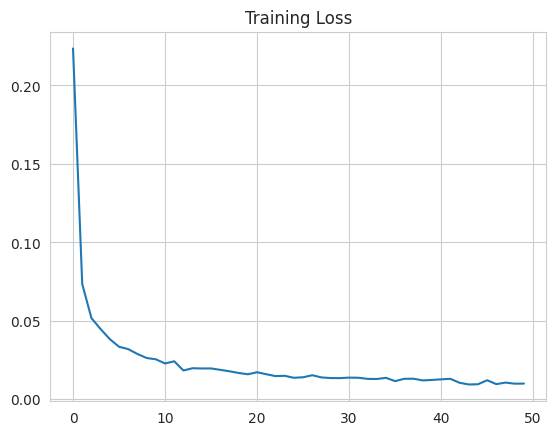

In [6]:
print("--- Training Deep Classifier on CUDA ---")

# Define Deep Classifier
class DeepClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Prepare Tensors
X_t = torch.tensor(X_train_final).to(device)
y_t = torch.tensor(y_train_bal.values).long().to(device)

train_ds = TensorDataset(X_t, y_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

# Initialize
num_classes = len(np.unique(y_train_bal))
clf_model = DeepClassifier(X_train_final.shape[1], num_classes).to(device)
optimizer = optim.AdamW(clf_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Training Loop
epochs = 50
print(f"Training for {epochs} epochs...")
loss_history = []

for epoch in range(epochs):
    clf_model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = clf_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    loss_history.append(epoch_loss / len(train_dl))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_history[-1]:.4f}")

plt.plot(loss_history)
plt.title("Training Loss")
plt.show()

--- Loading NSL-KDD for Validation ---

>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): 79.48%

Classification Report:
              precision    recall  f1-score   support

         dos       0.96      0.76      0.85      7636
      normal       0.73      0.96      0.83      9711
       probe       0.71      0.81      0.76      2423
         r2l       0.96      0.29      0.45      2574
         u2r       0.60      0.14      0.23       200

    accuracy                           0.79     22544
   macro avg       0.79      0.59      0.62     22544
weighted avg       0.83      0.79      0.78     22544



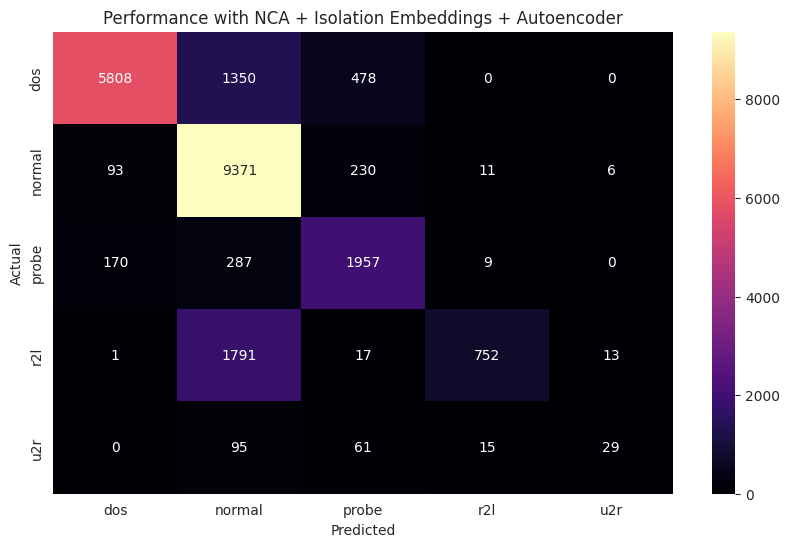

In [7]:
def predict_risk_sensitive_torch(model, X_np, encoder, risk_factors):
    model.eval()
    # Batch processing for inference to save memory
    loader = DataLoader(TensorDataset(torch.tensor(X_np)), batch_size=1024, shuffle=False)
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            
    probs = np.concatenate(all_probs)
    classes = encoder.classes_
    
    # Apply Risk Factors
    for cls, factor in risk_factors.items():
        if cls in classes:
            idx = np.where(classes == cls)[0][0]
            probs[:, idx] *= factor
            
    pred_indices = np.argmax(probs, axis=1)
    return encoder.inverse_transform(pred_indices)

RISK_FACTORS = {
    'r2l': 3.0,  
    'u2r': 3.0,  
    'probe': 1.2
}

# Note: We reuse 'le_y' which was saved earlier, instead of fitting a new one

# --- NSL-KDD Validation ---
print("--- Loading NSL-KDD for Validation ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    # Load
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    X_nsl = df_nsl.drop(['label', 'category'], axis=1)
    y_nsl = df_nsl['category']
    
    # 1. Vectorize (Same Encoders)
    X_nsl_vec, _ = prepare_vector_input(X_nsl, fit=False, encoders=encoders)
    
    # 2. Transform Pipeline
    # A. Scale
    X_nsl_sc = scaler.transform(X_nsl_vec).astype(np.float32)
    # B. NCA Project
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    # C. Isolation Embeddings
    iso_feats_nsl_final = []
    for cls in unique_classes:
         if cls in iso_models:
             iso = iso_models[cls]
             iso_feats_nsl_final.append(iso.decision_function(X_nsl_sc).reshape(-1, 1).astype(np.float32))
    X_nsl_iso = np.hstack(iso_feats_nsl_final)
    
    # D. Autoencoder Score
    X_nsl_ae = get_recon_error_torch(ae_model, X_nsl_sc)

    # E. Stack
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    
    # 3. Predict
    y_nsl_pred = predict_risk_sensitive_torch(clf_model, X_nsl_final, le_y, RISK_FACTORS)
    
    # Evaluate
    acc = accuracy_score(y_nsl, y_nsl_pred)
    print(f"\n>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_nsl, y_nsl_pred))
    
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_nsl_pred, labels=labels)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
    plt.title("Performance with NCA + Isolation Embeddings + Autoencoder")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

except Exception as e:
    print(f"Error: {e}")